## Project overview
You are recently hired as a data scientist for a video streaming company. This company recently lossing more customers. The stakeholders have decided to use data science to khow the reason and figure out the solution.

## 1. Define Scope of the project
#### Problem statement:
A video streming company is experiencing a decline in premium subscription, with significant number of customers canceling their subscription plans. The goal is to understand the factors contributing customers churn and develop strategies.

#### Objective and Goals
Analyze customer behaviour and usage pattern to identify main factors contributing customers churn

#### Data requirements
Gender and demographic = Age, sex, location
Usage = How much time they have spent, what are they search, how much time they spent on each video, how many times they open the app in a day (daily active users)
Subscription plan: How frequent they purchase the plan, how many times they come to the subscription landing page
Engagement with add-ons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Streaming.csv")

df.sample(2)

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
4030,CUST004031,67.0,Female,13,North,Credit Card,2,1.0,19.65,165,34.61,1
4959,CUST004960,20.0,Female,7,South,Credit Card,2,10.0,16.44,188,51.57,0


### Remove data set which we dont need

In [3]:
df.drop(columns=['Subscription_Length', 'Payment_Method'], inplace=True)

df.sample(2)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
4764,CUST004765,54.0,Male,South,3,10.0,11.45,240,53.40,0
2693,CUST002694,54.0,Male,West,0,3.0,11.83,144,39.38,1


#### Understand the datatypes of the features

In [4]:
df.dtypes

Customer_ID                   str
Age                       float64
Gender                        str
Region                        str
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
dtype: object

 float32 vs float64 (short + clear)

float32
- 32 bits (4 bytes)
- less precision (~6–7 decimal digits)
- uses less memory, faster

float64:
- 64 bits (8 bytes)
- higher precision (~15–16 decimal digits)
- default in Python, more accurate

#### How to change data type if required

In [5]:
df['Age'].astype('float32')

0       56.0
1       69.0
2       46.0
3       32.0
4       60.0
        ... 
4995    24.0
4996    66.0
4997    26.0
4998    53.0
4999    36.0
Name: Age, Length: 5000, dtype: float32

Handle Missing data

In [6]:
# Check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   str    
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   str    
 3   Region                  5000 non-null   str    
 4   Support_Tickets_Raised  5000 non-null   int64  
 5   Satisfaction_Score      4500 non-null   float64
 6   Discount_Offered        5000 non-null   float64
 7   Last_Activity           5000 non-null   int64  
 8   Monthly_Spend           5000 non-null   float64
 9   Churned                 5000 non-null   int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 390.8 KB


In [7]:
#another way to check for missing values
df.isna().sum()

Customer_ID                 0
Age                       500
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [8]:
# percentage of missing values
df.isna().mean()*100

Customer_ID                0.0
Age                       10.0
Gender                     0.0
Region                     0.0
Support_Tickets_Raised     0.0
Satisfaction_Score        10.0
Discount_Offered           0.0
Last_Activity              0.0
Monthly_Spend              0.0
Churned                    0.0
dtype: float64

### Imputation


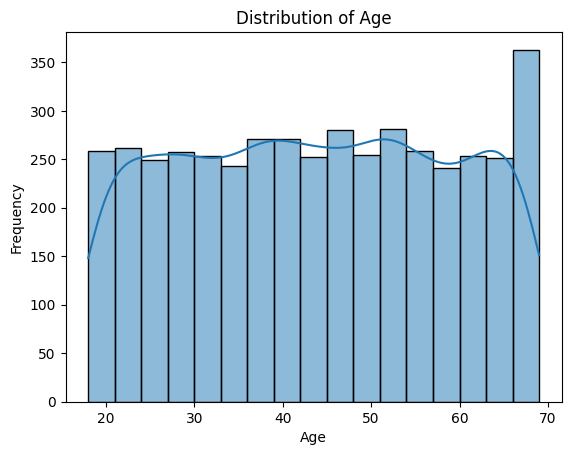

In [9]:
sns.histplot(data=df,kde=True,x=df['Age'].dropna())
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
#output is multimodal distribution ocording to the histogram from data

Data is not normaly dristibuted so we wll use KNNImputation

In [10]:
from sklearn.impute import KNNImputer, SimpleImputer # for imputing missing values
imputer = KNNImputer(n_neighbors=5) # initialize the imputer with 5 nearest neighbors
df[['Age']] = imputer.fit_transform(df[['Age']]) # impute missing values in the 'Age' column


In [11]:
# Enable experimental feature
from sklearn.experimental import enable_iterative_imputer  

# Import correct class
from sklearn.impute import IterativeImputer  

# Initialize imputer
imputer = IterativeImputer()

# Apply on column
df[['Age']] = imputer.fit_transform(df[['Age']])

In [12]:
df.isna().mean()*100

Customer_ID                0.0
Age                        0.0
Gender                     0.0
Region                     0.0
Support_Tickets_Raised     0.0
Satisfaction_Score        10.0
Discount_Offered           0.0
Last_Activity              0.0
Monthly_Spend              0.0
Churned                    0.0
dtype: float64

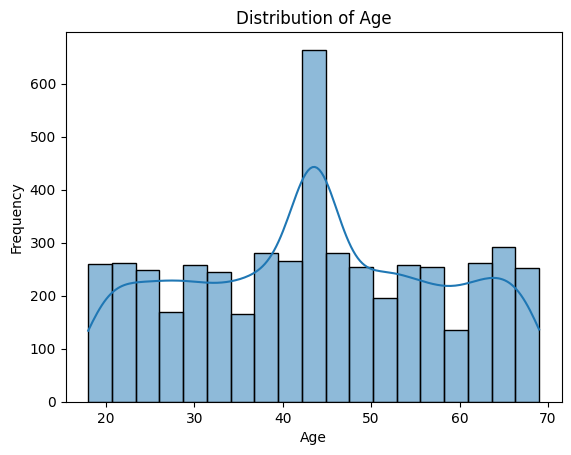

In [13]:
sns.histplot(data=df,kde=True,x=df['Age'].dropna())
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [14]:
df.head() # prints the first 5 rows of the DataFrame
df['Satisfaction_Score'].value_counts() # prints the count of each unique value in the 'Satisfaction_Score' column

Satisfaction_Score
6.0     477
4.0     469
10.0    467
7.0     463
1.0     450
8.0     449
9.0     443
2.0     439
5.0     436
3.0     407
Name: count, dtype: int64

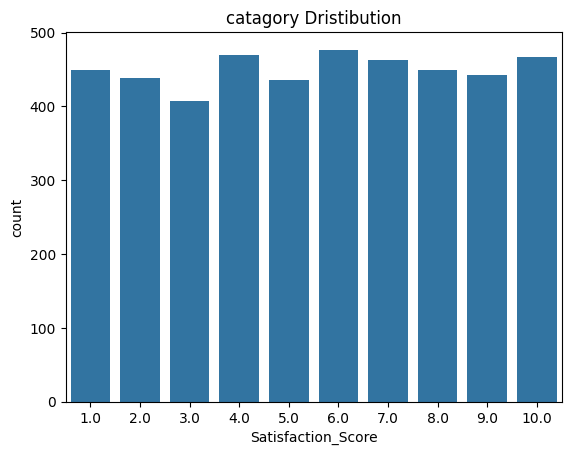

In [15]:
#visualize the discreate numerical column
sns.countplot(x=df['Satisfaction_Score'].dropna(), data=df)
plt.title("catagory Dristibution")
plt.xlabel("Satisfaction_Score")
plt.ylabel("count")
plt.show()

In [16]:
#impute missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent') # mode imputation
df[['Satisfaction_Score']] = imputer.fit_transform(df[['Satisfaction_Score']]) # impute missing values in the 'Satisfaction_Score' column

In [17]:
df.isna().sum() # check for missing values

Customer_ID               0
Age                       0
Gender                    0
Region                    0
Support_Tickets_Raised    0
Satisfaction_Score        0
Discount_Offered          0
Last_Activity             0
Monthly_Spend             0
Churned                   0
dtype: int64

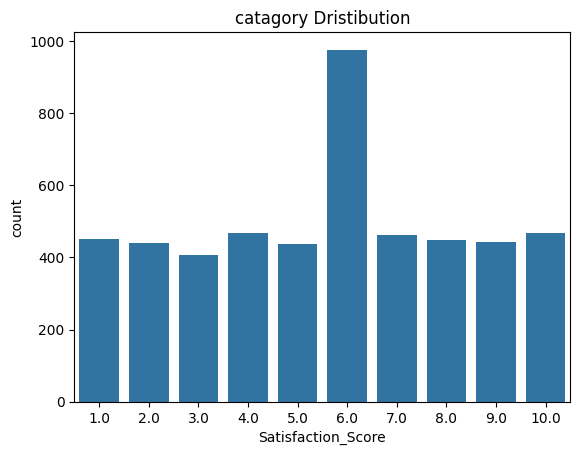

In [18]:
#visualize the discreate numerical column
sns.countplot(x=df['Satisfaction_Score'], data=df)
plt.title("catagory Dristibution")
plt.xlabel("Satisfaction_Score")
plt.ylabel("count")
plt.show()

### Data Cleaning 

*Remove typos, Duplicates, inconsistency from data

In [19]:
df.sample()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
3556,CUST003557,47.0,Female,South,0,3.0,15.79,132,42.86,1


In [20]:
df['Gender'].value_counts() # prints the count of each unique value in the 'Gender' column  

Gender
Female    2514
Male      2486
Name: count, dtype: int64

In [21]:
df['Region'].value_counts() # prints the count of each unique value in the 'Region' column

Region
West     1316
North    1243
South    1239
East     1202
Name: count, dtype: int64

In [22]:
df.describe() # prints a summary of the numerical columns in the DataFrame

#the column monthly_Spend is showing -ve values which is not possible 
# so there is typo in the dataset (something is wrong )

,Age,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,2.037000,5.591400,12.458404,181.441400,46.619784,0.448000
std,14.201213,1.422405,2.725423,4.325381,104.500951,9.522140,0.497338
min,18.000000,0.000000,1.000000,5.000000,1.000000,-5.060000,0.000000
25%,32.000000,1.000000,3.000000,8.700000,90.000000,39.897500,0.000000
50%,43.582222,2.000000,6.000000,12.500000,182.000000,46.625000,0.000000
75%,55.000000,3.000000,8.000000,16.190000,271.000000,53.210000,1.000000
max,69.000000,9.000000,10.000000,20.000000,364.000000,137.310000,1.000000


In [23]:
#lets resolve the issue
df[df['Monthly_Spend'] > 0]['Monthly_Spend'].min() # prints the minimum value in the 'Monthly_Spend' column for rows where 'Monthly_Spend' is greater than 0

#what ever minimum value we get we will replace the -ve values with the minimum value

np.float64(21.77)

In [24]:
# Replace -ve values with the minimum value
min_monthly_spend = df[df['Monthly_Spend'] > 0]['Monthly_Spend'].min()
df['Monthly_Spend'] = np.where(df['Monthly_Spend'] < 0, min_monthly_spend, df['Monthly_Spend'])

In [25]:
df.describe()

,Age,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,2.037000,5.591400,12.458404,181.441400,46.630208,0.448000
std,14.201213,1.422405,2.725423,4.325381,104.500951,9.480555,0.497338
min,18.000000,0.000000,1.000000,5.000000,1.000000,21.770000,0.000000
25%,32.000000,1.000000,3.000000,8.700000,90.000000,39.897500,0.000000
50%,43.582222,2.000000,6.000000,12.500000,182.000000,46.625000,0.000000
75%,55.000000,3.000000,8.000000,16.190000,271.000000,53.210000,1.000000
max,69.000000,9.000000,10.000000,20.000000,364.000000,137.310000,1.000000


### Detect Outliers

In [26]:
df['Discount_Offered'].describe() # prints a summary of the numerical columns in the DataFrame

#we found no outlier


count    5000.000000
mean       12.458404
std         4.325381
min         5.000000
25%         8.700000
50%        12.500000
75%        16.190000
max        20.000000
Name: Discount_Offered, dtype: float64

<Axes: xlabel='Discount_Offered', ylabel='Density'>

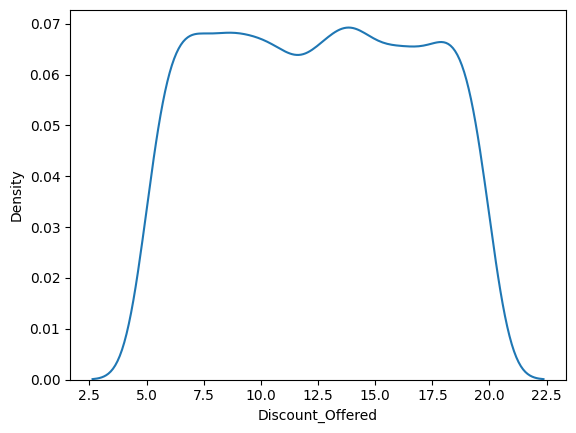

In [27]:
sns.kdeplot(x=df['Discount_Offered'], data=df) # plots a kernel density estimate (KDE) of the 'Discount_Offered' column

In [28]:
df['Monthly_Spend'].describe() 
#try to find the outlier
#max - 137.310000 quite high suspected as outlier

count    5000.000000
mean       46.630208
std         9.480555
min        21.770000
25%        39.897500
50%        46.625000
75%        53.210000
max       137.310000
Name: Monthly_Spend, dtype: float64

<Axes: xlabel='Monthly_Spend', ylabel='Density'>

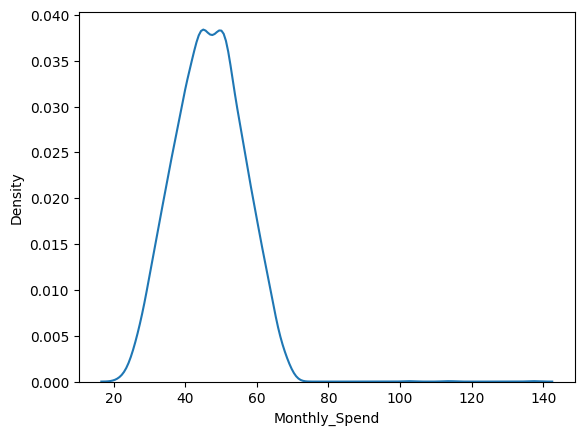

In [29]:
sns.kdeplot(x=df['Monthly_Spend'], data=df)

In [30]:
df[df['Monthly_Spend'] > 75]

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
1935,CUST001936,43.0,Male,South,1,1.0,6.00,135,102.44,1
2784,CUST002785,26.0,Male,East,1,10.0,13.03,69,137.31,0
4888,CUST004889,47.0,Female,South,4,8.0,5.16,96,113.66,0


In [31]:
mean = df['Monthly_Spend'].mean() # calculate the mean
std = df['Monthly_Spend'].std() # calculate the standard deviation


upper_bound = mean + 3 * std  # calculate the upper bound
lower_bound = mean - 3 * std  # calculate the lower bound

within_3rd_std = df[(df['Monthly_Spend'] >= lower_bound) & (df['Monthly_Spend'] <= upper_bound)] # filter the DataFrame to only include rows where the 'Monthly_Spend' is within 3 standard deviations of the mean


# count and percentage 
count_within = within_3rd_std.shape[0] # total number of rows
total_count = df.shape[0] # total number of rows

percentage = (count_within / total_count) * 100 # calculate the percentage

percentage

99.94

In [32]:
#lets remove the outlier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

month_spend_scaled = scaler.fit_transform(df[['Monthly_Spend']]) #  there is error can you solve? AI? can you help? hey i need help -> 

mask = np.abs(month_spend_scaled) < 3
df = df[mask.flatten()]

In [33]:
df[df['Monthly_Spend'] > 75] #no outlier

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned


<Axes: xlabel='Monthly_Spend', ylabel='Density'>

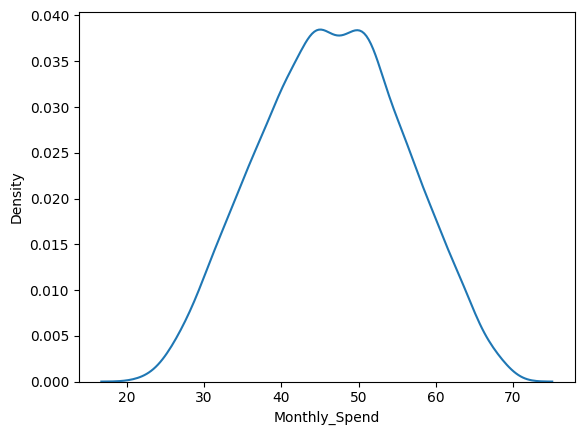

In [34]:
sns.kdeplot(x=df['Monthly_Spend'], data=df) # plots a kernel density estimate (KDE) of the 'Monthly_Spend' column

### EDA
Try to better understand the customers who cancelled:
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?
* What is the average satisfaction score of customers who cancelled
* What percentage of male and female customers who cancelled the subscription
* How many support ticket raised by customers who cancelled vs who don't
* What is the relation between monthly spend and last activity - customers get their ROI
* In which Region the cancellation is much higher

In [35]:
df.head()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,South,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,East,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,East,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,West,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,East,2,6.0,13.18,65,45.97,0


In [36]:
# view customor who cancelled and the discount offered less than 10
df[(df['Churned'] == 1) & (df['Discount_Offered'] < 10)].shape[0] # total number of rows 

741

In [37]:
# view customor who did not cancel and the discount offered less than 10
df[(df['Churned'] == 0) & (df['Discount_Offered'] < 10)].shape[0] # total number of rows 

949

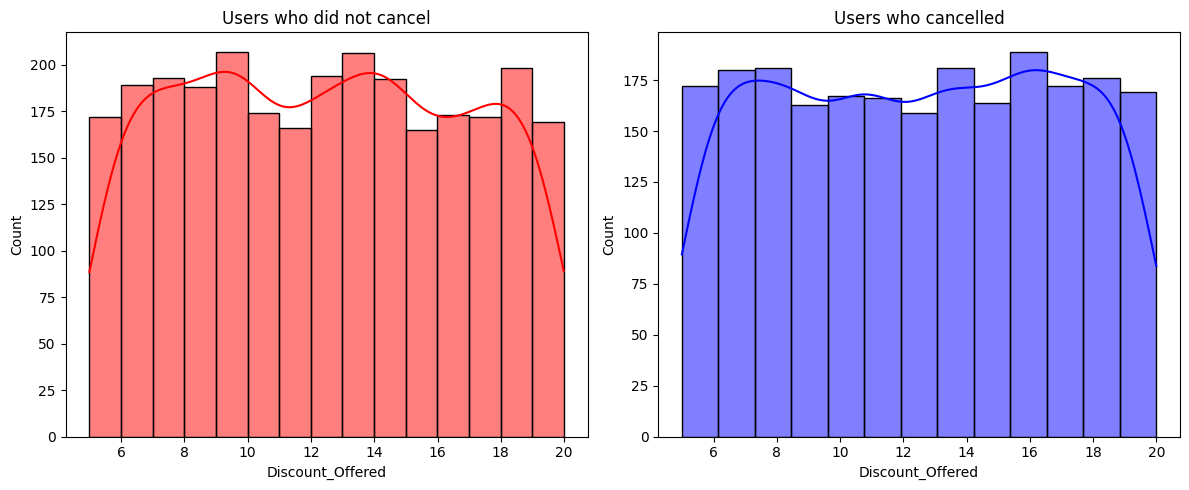

In [40]:
user_df = df[df['Churned'] == 0]['Discount_Offered'] # view customor who did not cancel and the discount offered less than 10
cancelled_users_df = df[df['Churned'] == 1]['Discount_Offered'] # view customor who cancelled and the discount offered less than 10
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # create a figure with 1 row and 2 columns of subplots

sns.histplot(x=user_df, data=df, ax=axes[0], kde=True, color='r') # plot a histogram with KDE for the 'Discount_Offered' column of users who did not cancel
axes[0].set_title('Users who did not cancel') # set the title for the first subplot
sns.histplot(x=cancelled_users_df, data=df, ax=axes[1], kde=True, color='b') # plot a histogram with KDE for the 'Discount_Offered' column of users who cancelled
axes[1].set_title('Users who cancelled') # set the title for the second subplot

plt.tight_layout() # adjust the layout of the subplots
plt.show() # display the plot

### Summary: Discountis not the main reason for customer for cancellation as the distribution of discount offered is similar for both groups (users who cancelled and users who did not cancel).

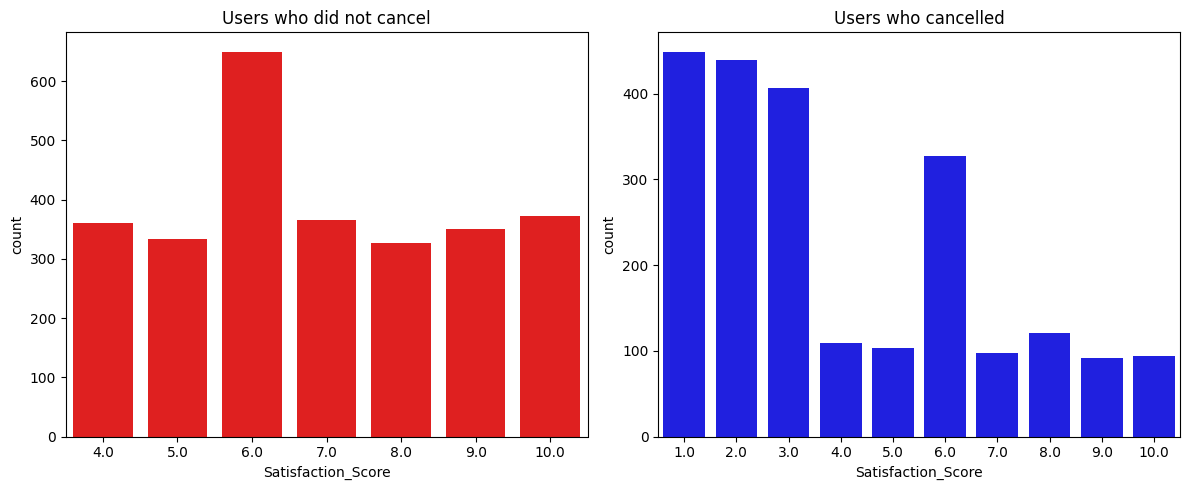

In [43]:
user_df = df[df['Churned'] == 0]['Satisfaction_Score'] # view customer who did not cancel and the satisfaction score
cancelled_users_df = df[df['Churned'] == 1]['Satisfaction_Score'] # view customer who cancelled and the satisfaction score
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # create a figure with 1 row and 2 columns of subplots

sns.countplot(x=user_df, data=df, ax=axes[0], color='r') # plot a histogram with KDE for the 'Discount_Offered' column of users who did not cancel
axes[0].set_title('Users who did not cancel') # set the title for the first subplot
sns.countplot(x=cancelled_users_df, data=df, ax=axes[1], color='b') # plot a histogram with KDE for the 'Discount_Offered' column of users who cancelled
axes[1].set_title('Users who cancelled') # set the title for the second subplot

plt.tight_layout() # adjust the layout of the subplots
plt.show() # display the plot



In [ ]:
## We can say that the customers who did not cancel have a higher satisfaction score compared to those who cancelled. 
# The histogram for users who did not cancel shows a more even distribution of satisfaction scores, while the histogram for users who cancelled shows a higher concentration of lower satisfaction scores. 
# This suggests that customers with lower satisfaction scores are more likely to cancel their subscriptions.

In [44]:
df[df['Churned'] == 1]['Satisfaction_Score'].mean() # prints the mean satisfaction score for users who cancelled

np.float64(3.9673961589995534)

In [45]:
df[df['Churned'] == 0]['Satisfaction_Score'].mean() # prints the mean satisfaction score for users who did not cancel

np.float64(6.908992023205221)

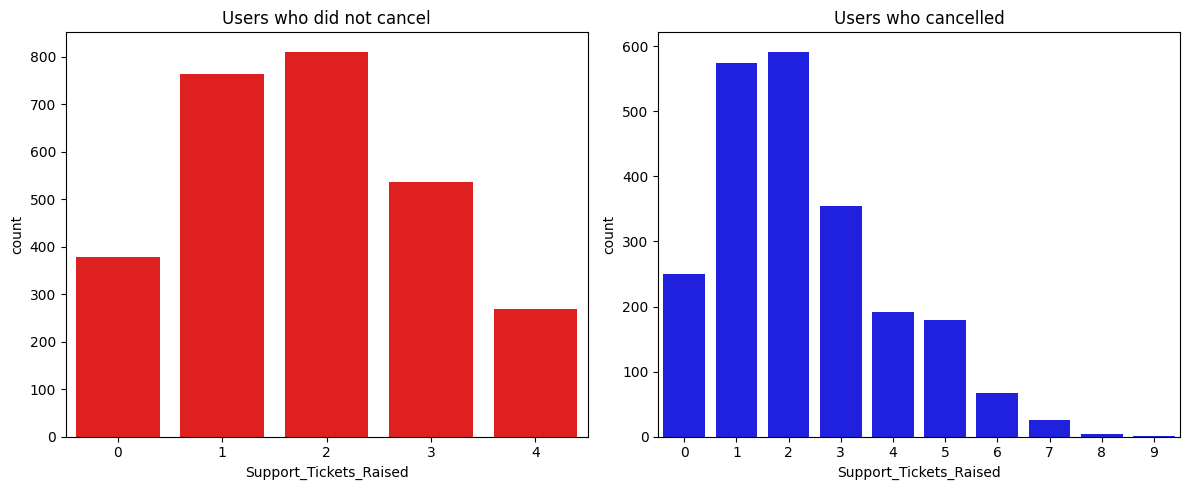

In [46]:
user_df = df[df['Churned'] == 0]['Support_Tickets_Raised'] # view customer who did not cancel and the satisfaction score
cancelled_users_df = df[df['Churned'] == 1]['Support_Tickets_Raised'] # view customer who cancelled and the satisfaction score
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # create a figure with 1 row and 2 columns of subplots

sns.countplot(x=user_df, data=df, ax=axes[0], color='r') # plot a histogram with KDE for the 'Discount_Offered' column of users who did not cancel
axes[0].set_title('Users who did not cancel') # set the title for the first subplot
sns.countplot(x=cancelled_users_df, data=df, ax=axes[1], color='b') # plot a histogram with KDE for the 'Discount_Offered' column of users who cancelled
axes[1].set_title('Users who cancelled') # set the title for the second subplot

plt.tight_layout() # adjust the layout of the subplots
plt.show() # display the plot


In [ ]:
## Summary: Support ticket is not the factor that is leading to the cancellation of the subscription. 
# Both users who cancelled and those who did not cancel have a similar distribution of support tickets raised, with most users raising 0 or 1 support ticket. 
# This suggests that the number of support tickets raised does not have a significant impact on whether a customer cancels their subscription or not.

### Conclusion
- Most customers who cancelled their subscriptions did so because they weren’t happy with the platform. They gave low ratings before leaving, which shows they were not satisfied
- Things like discounts, gender, region, or subscription price don’t seem to be the reason for cancellation.
- The real issue might be poor content—like bad movies or low-quality audio—but this kind of feedback isn’t included in the dataset.

### Feature Engineering

In [47]:
df.head()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,South,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,East,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,East,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,West,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,East,2,6.0,13.18,65,45.97,0


In [48]:
df.drop(columns=['Customer_ID'], inplace=True)

In [50]:
from sklearn.model_selection import train_test_split # for splitting the data into training and testing sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder # for scaling numerical features and encoding categorical features
from sklearn.compose import ColumnTransformer # for applying different preprocessing steps to different columns
from sklearn.pipeline import Pipeline # for creating a pipeline of preprocessing steps


# Step 2: Split features and target
X = df.drop('Churned', axis=1)
y = df['Churned']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Define preprocessing
numeric_features = ['Age', 'Support_Tickets_Raised', 'Satisfaction_Score',
                    'Discount_Offered', 'Last_Activity', 'Monthly_Spend']
categorical_features = ['Gender', 'Region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Step 5: Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)
])

# Step 6: Transform the data
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# Output shapes and preview
print("Transformed training shape:", X_train_transformed)
print("Transformed test shape:", X_test_transformed)

Transformed training shape: [[ 1.58150715  0.66514839  0.88932384 ...  1.          0.
   0.        ]
 [ 0.1044449  -0.7264235   0.15671308 ...  0.          1.
   0.        ]
 [-0.1769003  -0.03063756  1.25562921 ...  1.          0.
   0.        ]
 ...
 [-1.09127216 -0.03063756  1.25562921 ...  0.          0.
   0.        ]
 [ 0.24511749 -0.03063756  1.62193459 ...  0.          0.
   1.        ]
 [ 0.00472366 -0.03063756 -0.57589767 ...  0.          0.
   1.        ]]
Transformed test shape: [[-1.30228106 -0.7264235  -0.94220305 ...  0.          0.
   0.        ]
 [ 0.52646268  0.66514839 -0.94220305 ...  0.          1.
   0.        ]
 [ 0.00472366 -0.03063756  0.88932384 ...  0.          0.
   0.        ]
 ...
 [-0.95059957 -0.03063756 -0.20959229 ...  1.          0.
   0.        ]
 [ 0.45612638 -0.03063756  1.62193459 ...  0.          0.
   0.        ]
 [-1.51328995 -0.7264235   0.15671308 ...  0.          0.
   0.        ]]
